In [21]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [22]:
#ПАРАМЕТРЫ СИСТЕМЫ

a = 1/3
p = 1
q = 0.8
t_k = 6

In [23]:
#Определяем сопряженную систему и граничные условия

def adjoint_system(t, psi):
  psi_1, psi_2 = psi
  dpsi_1 = psi_2
  dpsi_2 = -psi_1 + 2*a*psi_2
  return [dpsi_1, dpsi_2]

psi_t_k = [1, 0]

In [24]:
#Решаем сопряженную систему в обратном времени

sol_psi = solve_ivp(adjoint_system, [t_k, 0], psi_t_k, t_eval = np.linspace(t_k, 0, 5000))

#Разворачиваем от 0 к t_k
t = sol_psi.t[::-1]
psi = sol_psi.y[:, ::-1]

In [25]:
#\kappa(t) = \psi_2(t)

kappa = psi[1]

In [26]:
#Ищем пересечение с нулем

zero_crossings = []

for i in range(len(kappa) - 1):
    if kappa[i] == 0:
        zero_crossings.append(t[i])
    elif kappa[i] * kappa[i + 1] < 0: 
        zero_crossings.append((t[i], t[i + 1]))

def kappa_fun(time):
    return np.interp(time, t, kappa)

root = None
if zero_crossings:
    for z in zero_crossings:
        if isinstance(z, tuple):
            sol_root = root_scalar(kappa_fun, bracket=z)
            if sol_root.converged:
                root = sol_root.root
                print("kappa меняет знак в точке: ", root)
                break

kappa меняет знак в точке:  2.6674715602587624


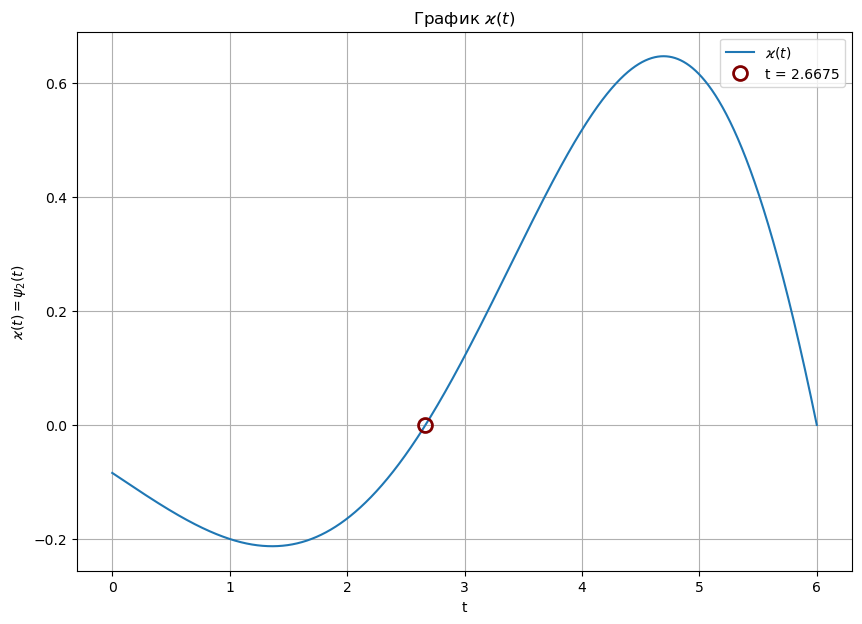

In [27]:
#Рисуем график kappa(t)

plt.figure(figsize = (10,7))
plt.plot(t, kappa, label = r"$\varkappa(t)$")

if root is not None:
    plt.plot(root, 0, 'o', markersize = 10, markerfacecolor = 'none', markeredgecolor = 'maroon', 
             markeredgewidth = 2, label = f"t = {root:.4f}")

plt.xlabel(r"t")
plt.ylabel(r"$\varkappa(t) = \psi_2(t)$")
plt.title(r"График $\varkappa(t)$")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#Функция sigma(t)

sigma = cumulative_trapezoid(kappa, t, initial = 0) #интегрирование методом трапеций 


In [29]:
#Решаем систему на \tilde{t}_1 = t1 и \tilde{\tilde{t}}_1 = t2

def solve_system_sigma(t, sigma, p, q):
   
    delta_t = 2.0 * q / p

    # Интерполяция sigma(t)
    sigma_inter = interp1d(t, sigma, kind = 'cubic', fill_value = "extrapolate")

    def F(t2):
        return sigma_inter(t2) - sigma_inter(t2 - delta_t)


    #Сетка для F
    t2_min = t[0] + delta_t
    t2_max = t[-1]

    grid = np.linspace(t2_min, t2_max, 1000)
    F_vals = F(grid)

    t2_root = None
    for i in range(len(grid) - 1):
        if F_vals[i] == 0:
            t2_root = grid[i]
            break
        if F_vals[i] * F_vals[i + 1] < 0:
            sol = root_scalar(F, bracket = [grid[i], grid[i + 1]])
            if sol.converged:
                t2_root = sol.root
                break

    if t2_root is None:
        raise RuntimeError("ERROR")

    t1_root = t2_root - delta_t
    return t1_root, t2_root

In [30]:
t1, t2 = solve_system_sigma(t, sigma, p, q)
print("t_1 =", t1)
print("t_2 =", t2)
print("Проверка: t_2 - t_1 =", t2 - t1, "Должно быть =", 2 * q / p)

t_1 = 1.7935432751375404
t_2 = 3.3935432751375405
Проверка: t_2 - t_1 = 1.6 Должно быть = 1.6


In [31]:
# Значения sigma в найденных точках
sigma1 = np.interp(t1, t, sigma)
sigma2 = np.interp(t2, t, sigma)

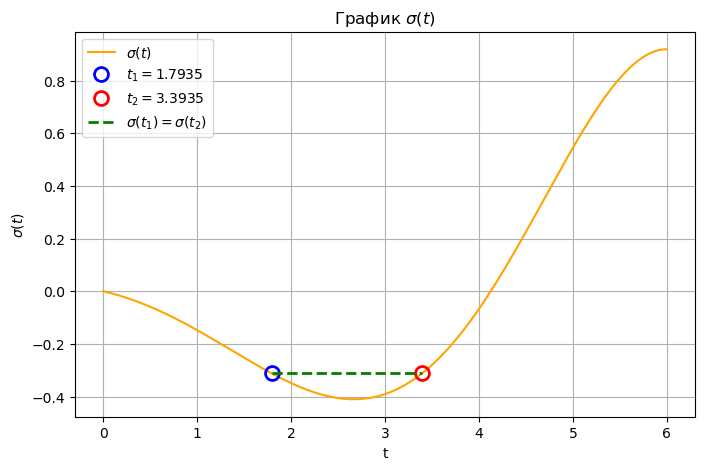

In [32]:
plt.figure(figsize = (8, 5))

# График sigma(t)
plt.plot(t, sigma, color = 'orange', label = r"$\sigma(t)$")

plt.plot(t1, sigma2, 'o', markersize = 10, markerfacecolor = 'none',
         markeredgecolor = 'blue', markeredgewidth = 2, label = f"$t_1 = {t1:.4f}$")

plt.plot(t2, sigma1, 'o', markersize = 10, markerfacecolor = 'none',
         markeredgecolor = 'red', markeredgewidth = 2, label = f"$t_2 = {t2:.4f}$")

plt.plot([t1, t2], [sigma1, sigma2], '--', color = 'green', linewidth = 2,
         label = r"$\sigma(t_1)=\sigma(t_2)$")

plt.xlabel("t")
plt.ylabel(r"$\sigma(t)$")
plt.title(r"График $\sigma(t)$")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
sgn = np.sign(np.interp(t1, t, kappa)) #Cмотрим на знак kappa(t1), даже если t1 не в сетке 

In [34]:
#Сетка по времени для v0(t)

t_v = np.linspace(0, t_k, 5000)
v0 = np.zeros_like(t_v)

In [35]:
#Строим куски возмущения

# 0 <= t <= t1
mask1 = (t_v >= 0) & (t_v <= t1)
v0[mask1] = q * sgn

# t1 <= t <= t2
mask2 = (t_v >= t1) & (t_v <= t2)
v0[mask2] = (q - p * (t_v[mask2] - t1)) * sgn

# t2 <= t <= t_k
mask3 = (t_v >= t2) & (t_v <= t_k)
v0[mask3] = -q * sgn

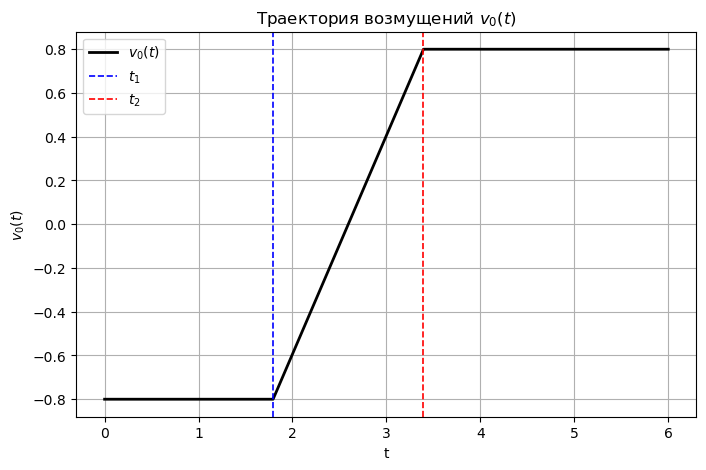

In [36]:
#Рисуем траекторию возмущений
plt.figure(figsize = (8, 5))

plt.plot(t_v, v0, color = 'black', linewidth = 2, label = r"$v_0(t)$")

plt.axvline(t1, color = 'blue', linestyle="--", linewidth = 1.2, label = r"$t_1$")
plt.axvline(t2, color = 'red', linestyle="--", linewidth = 1.2, label = r"$t_2$")

plt.xlabel("t")
plt.ylabel(r"$v_0(t)$")
plt.title(r"Траектория возмущений $v_0(t)$")
plt.grid(True)
plt.legend()
plt.show()

In [37]:
#В самую исходную систему на x подставляем найденное наихудшее возмущение

def system_v0(t_cur, x):
    v = np.interp(t_cur, t_v, v0)
    x1, x2 = x
    dx1 = x2
    dx2 = -x1 - 2*a*x2 + v
    return [dx1, dx2]

x0 = [0.0, 0.0]

sol_x = solve_ivp(system_v0, [0, t_k], x0, t_eval = t_v)

x1_traj = sol_x.y[0]
x2_traj = sol_x.y[1]

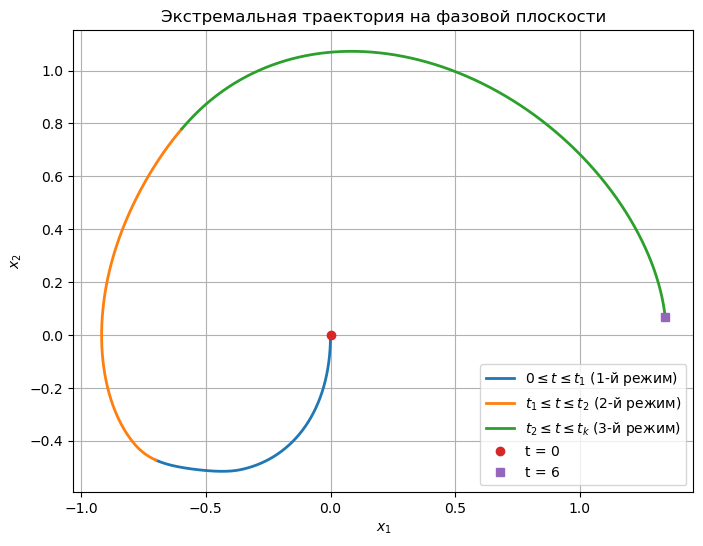

In [38]:
#Рисуем экстремальную траекторию на фазовой плоскости 

plt.figure(figsize = (8, 6))

#Участок с первым возмущением (v = q * sign)
plt.plot(x1_traj[mask1], x2_traj[mask1], label = r"$0 \leq t \leq t_1$ (1-й режим)",linewidth = 2)

#Участок с линейным наклоном
plt.plot(x1_traj[mask2], x2_traj[mask2], label = r"$t_1 \leq t \leq t_2$ (2-й режим)", linewidth = 2)

#Участок с третьим возмущением (v = -q * sign)
plt.plot(x1_traj[mask3], x2_traj[mask3], label = r"$t_2 \leq t \leq t_k$ (3-й режим)", linewidth = 2)


plt.plot(x1_traj[0], x2_traj[0], 'o', label = "t = 0")
plt.plot(x1_traj[-1], x2_traj[-1], 's', label = fr"t = {t_k}")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Экстремальная траектория на фазовой плоскости")
plt.grid(True)
plt.legend()
plt.show()


In [39]:
#Считаем максимальное отклонение через интеграл 
#x_1(t_k) = \int_0^{t_k} \kappa(t) v_0(t) dt

def max_deviation(t, kappa, t_v, v0):

    #Интерполируем κappa(t) на ту же сетку, что и v0(t)
    kappa_interp = interp1d(t, kappa, kind = 'cubic', fill_value = "extrapolate")
    kappa_on_tv = kappa_interp(t_v)

    x1_tk = np.trapz(kappa_on_tv * v0, t_v) #Считаем интеграл 
    
    return x1_tk

x1_max = max_deviation(t, kappa, t_v, v0)

print("Максимальное отклонение x1(t_k):", x1_max)
print("Модуль максимального отклонения |x1(t_k)|:", abs(x1_max))

Максимальное отклонение x1(t_k): 1.3375395475090714
Модуль максимального отклонения |x1(t_k)|: 1.3375395475090714


In [40]:
#Проверка 

print("Численно по системе:", x1_traj[-1])

Численно по системе: 1.3418482713786388
